# Notebook métricas de evaluación con RR Lyrae

Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

En esta actividad trabajaremos con un problema de clasificación binaria: distinguir estrellas **RR Lyrae** de otras estrellas a partir de sus colores fotométricos.

### Los objetivos son
- entrenar un clasificador simple
- evaluar su rendimiento con distintas métricas
- interpretar una matriz de confusión
- comparar accuracy con precision, recall y F1
- discutir qué métrica conviene según el objetivo científico

### Contexto
Las RR Lyrae son estrellas variables pulsantes muy importantes en astronomía. En un catálogo grande, un clasificador puede ayudarnos a encontrar candidatas RR Lyrae, pero no basta con mirar solo el accuracy.


### Descripción de los datos
El set de datos que usará para esta tarea es sobre estrellas. Las características son colores en distintos filtros del [sistema ugriz de SDSS](https://www.physics.unlv.edu/~jeffery/astro/photometry/photometry_sdss.html), que son un indicador si la estrella emite luz más azul, verde, amarilla o roja. Queremos predecir a partir de estas características si la estrella es un tipo especial de estrella llamada variable RR Lyrae.

- Las características son los colores u-g, g-r, r-i, i-z
- El target es 0 (no RRLyrae) y 1 (RRLyrae)


In [62]:
import pandas as pd
import numpy as np

import sklearn.tree
from sklearn.tree import DecisionTreeClassifier #modelo
from sklearn.tree import plot_tree #visualizacion arbol
from sklearn.model_selection import train_test_split
from sklearn import metrics #métricas
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate #validación cruzada
from sklearn.model_selection import KFold, StratifiedKFold #validación cruzada

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #matriz de confusión


from scipy import stats

In [63]:
from io import StringIO
from IPython.display import Image
import pydotplus
from sklearn.tree import export_graphviz

In [64]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

font = {'size': 8}

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=8)
matplotlib.rc('ytick', labelsize=8)
matplotlib.rcParams['figure.dpi'] = 300

pd.set_option('display.max_columns', 100) #Para poder visualizar todas las columnas del dataframe
pd.set_option('display.max_colwidth', 100)

## Primer paso: exploración de los datos

Siempre es importante hacer una análisis exploratorio del conjunto de datos que trabajaremos. Leemos el archivo como un dataframe y extraemos información básica

In [65]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:

#cargamos los datos como arreglos numpy
features= np.loadtxt("/content/drive/MyDrive/machine learning/RRLyrae_features_small.txt", delimiter=',')
targets= np.loadtxt("/content/drive/MyDrive/machine learning/RRLyrae_labels_small.txt", delimiter=',')


In [67]:
columnas = ["u-g", "g-r", "r-i", "i-z"]
df = pd.DataFrame(features, columns=columnas)
df["RR_Lyrae"] = targets.astype(int)

df.head()

,u-g,g-r,r-i,i-z,RR_Lyrae
0,0.311,0.714,0.093,0.204,0
1,0.332,0.965,0.122,0.032,0
2,0.394,1.019,0.147,0.096,0
3,0.285,0.865,0.120,0.039,0
4,0.386,0.977,0.181,0.080,0


### Preguntas
1. ¿Este es un problema de clasificación o regresión?
2. ¿Es un problema binario o multiclase?
3. ¿Qué representa la variable objetivo?
4. ¿Las clases están balanceadas o desbalanceadas?
5. ¿Por qué esto podría ser importante al elegir una métrica de evaluación?

1. Es un problema de clasificación (la variable objetivo es una categoría discreta con opciones 0 o 1, no un número continuo).
2. Es binario, ya que solo hay 2 clases: estrellas RR Lyrae / no RR Lyrae (no pulsantes).
3. La variable objetivo indica si la estrella es una variable RR Lyrae (1) o no (0).
4. Las clases están desbalanceadas: 2000 no-RRLyrae (80.5%) vs 483 RRLyrae (19.5%).
5. Es importante porque cuando están desbalanceadas el accuracy puede ser engañoso: un modelo que  siempre predice "no RR Lyrae" ya tendría 80.5% de accuracy sin aprender nada útil. Por eso hay que analizar: precision, recall y F1.

#### Haga una visualización de sólo dos columnas para revisar los colores de las RR Lyrae y las no RRLyrae

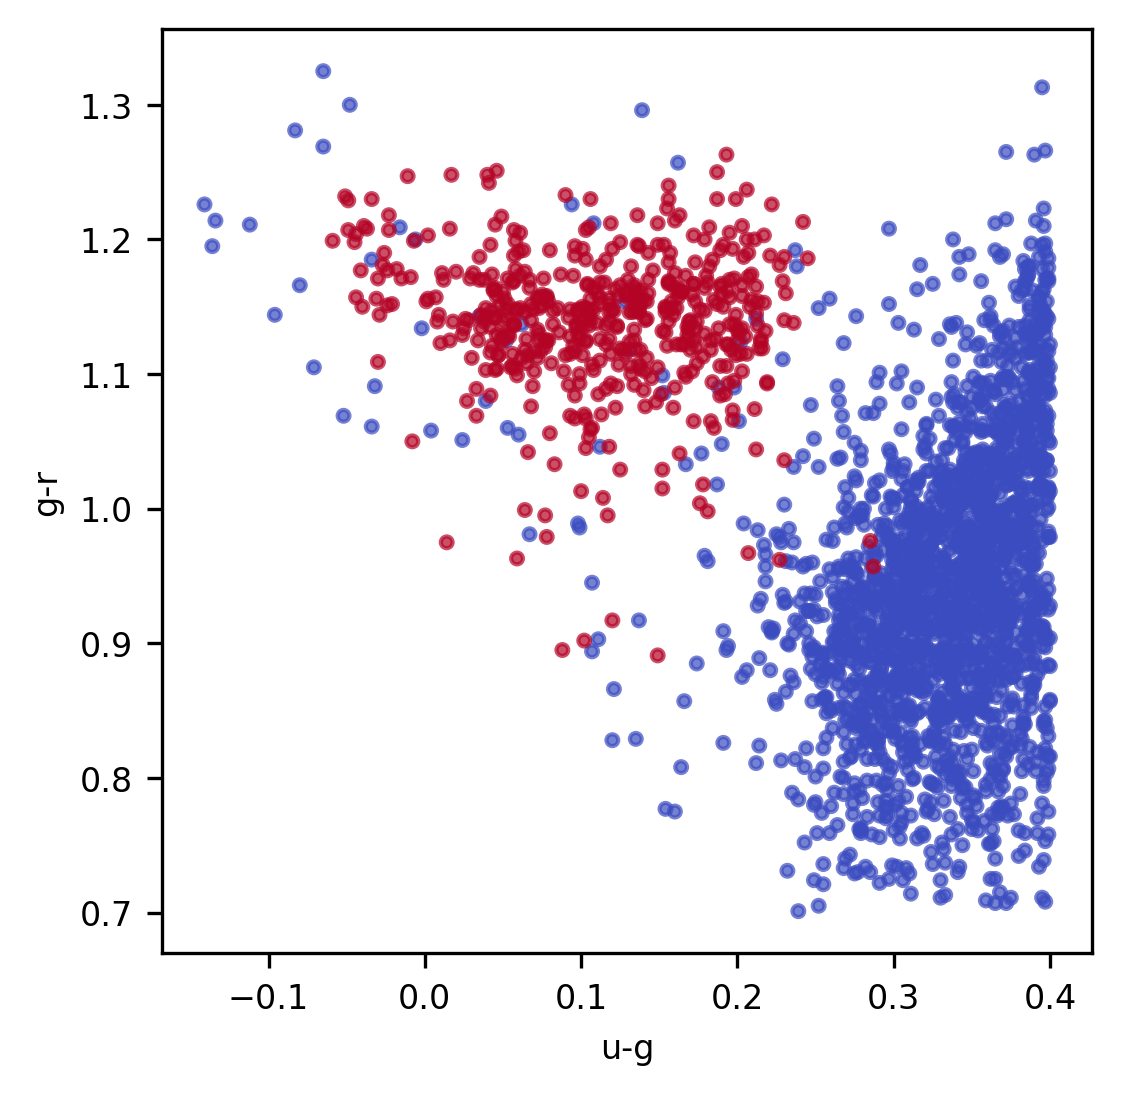

In [68]:
#complete la celda
plt.figure(figsize=(4,4))

sc=plt.scatter(df['u-g'], df['g-r'], c=df['RR_Lyrae'], cmap='coolwarm', s=8, alpha=0.7)

#agregamos label, para teneruna mejor visualización

plt.xlabel('u-g')
plt.ylabel('g-r')

plt.show()

### Pregunta
1. ¿Se observan regiones donde las clases parecen separarse?
2. A simple vista, ¿esperarías que un árbol de decisión funcione razonablemente bien?

Sí, se observa una tendencia clara: las estrellas RR Lyrae (en un color del mapa) se agrupan en una región del gráfico u-g vs g-r, que se distingue de la nube principal de estrellas normales, aunque hay algunos outliers que se sobreponen en los bordes.

A simple vista, esperaría que un árbol de decisión funcione relativamente bien, ya que existe una separación que se puede ver entre las clases.

#### Separe los datos en entrenamiento y prueba

In [69]:
X = df[["u-g", "g-r", "r-i", "i-z"]]
y = df["RR_Lyrae"]

In [70]:
#complete la celda
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size=0.3, random_state=42)

In [71]:
X_train.shape

(1738, 4)

### Antes de continuar

Las clases en este problema no están perfectamente balanceadas.

Piense en la forma en que podríamos separar los datos en entrenamiento y prueba, y responda:

1. ¿Qué problema podría ocurrir si hacemos la partición de manera completamente aleatoria, sin preocuparnos por la proporción de clases?
2. ¿Por qué eso podría afectar la evaluación del modelo?
3. ¿Qué tipo de precaución cree que sería razonable tomar al construir los conjuntos de entrenamiento y prueba en este caso?

1. Como las RR Lyrae tiene menos datos, una partición completamente aleatoria podría dejar muy pocas RR Lyrae en el conjunto de prueba, o desbalancear aún más la proporción entre train y test.

2. Si el set de prueba termina con muy pocos ejemplos de la clase RR lyrae, las métricas que dependen de ella (precision, recall, F1) se calcularían sobre muy pocos datos, podría generar que estas sean inestables y poco confiables Además, si el set de entrenamiento queda con una proporción de clases distinta a la real, el modelo podría aprender un sesgo erroneo con respecto a la realidad.

3. Usar una partición estratificada, que mantenga la misma proporción de clases (≈80.5% / 19.5%) tanto en entrenamiento como en prueba. En `train_test_split` esto se logra agregando el parámetro `stratify=y`

#### Ahora entrenaremos un árbol de decisión (modelo base)

In [72]:
model_tree = DecisionTreeClassifier(random_state=42)
model_tree.fit(X_train, y_train)
#entrene el modelo y genere las predicciones
y_pred=model_tree.predict(X_test)


#### Visualicemos el árbol

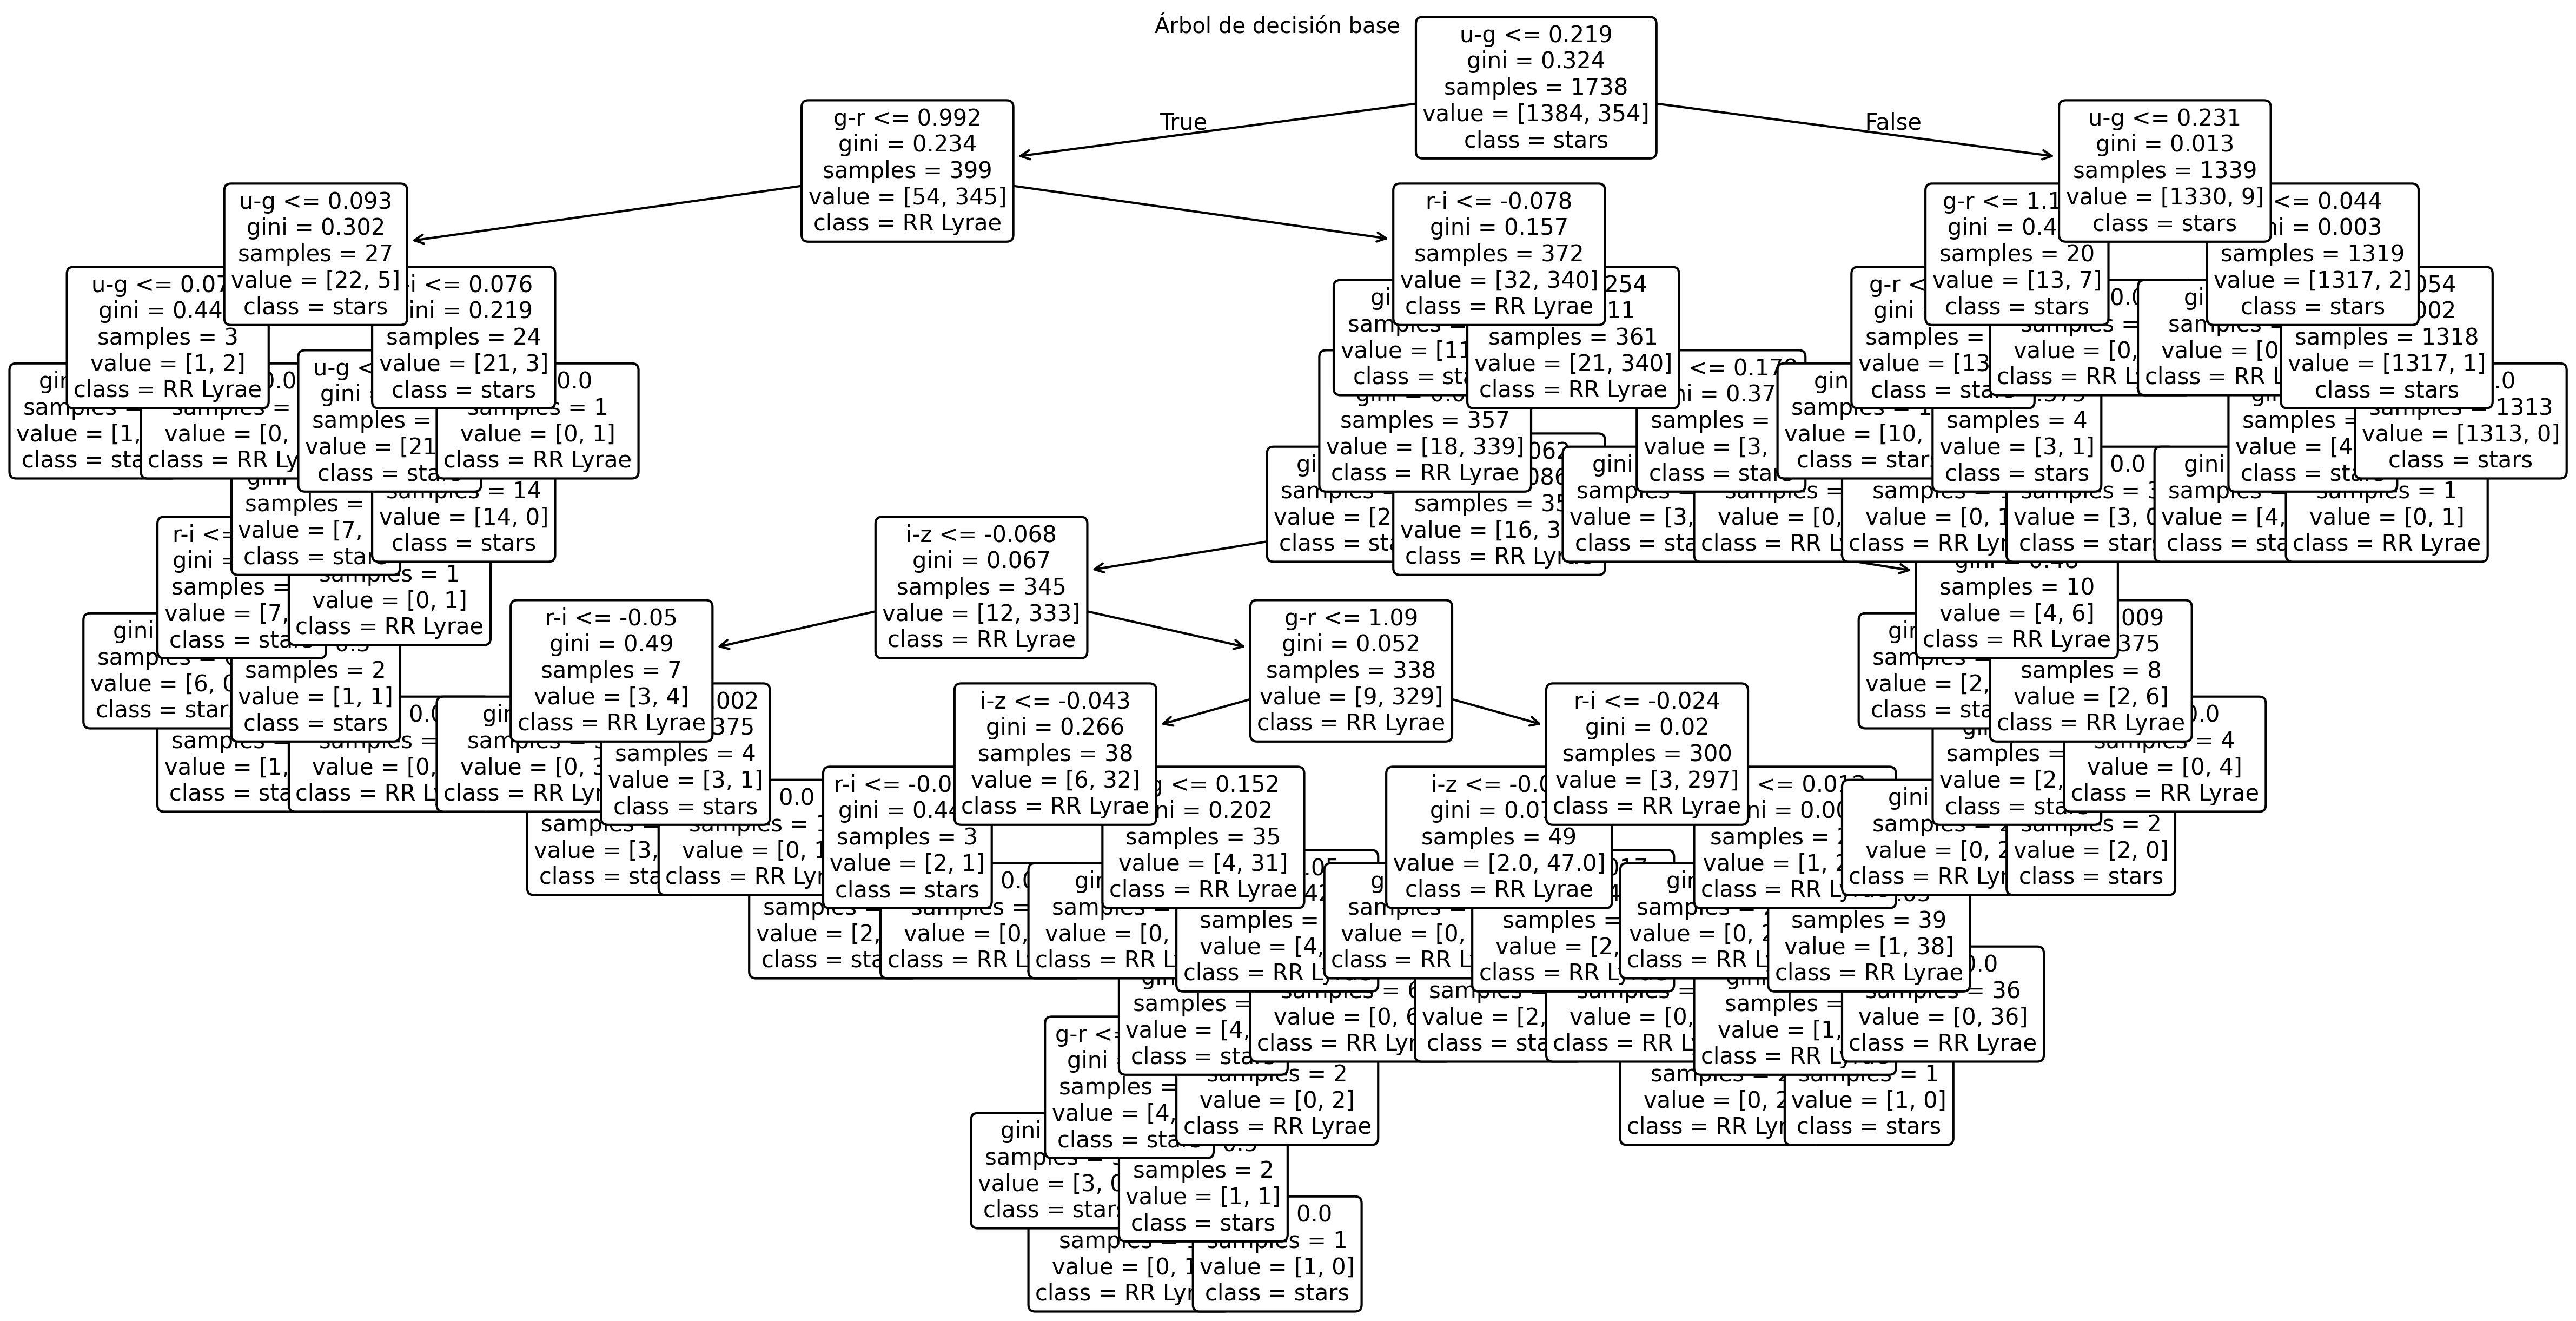

In [73]:
plt.figure(figsize=(20,10))

plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=["stars", "RR Lyrae"],
    filled=False,
    rounded=True,
    #max_depth=3,
    fontsize=10
)

plt.title("Árbol de decisión base")
plt.show()

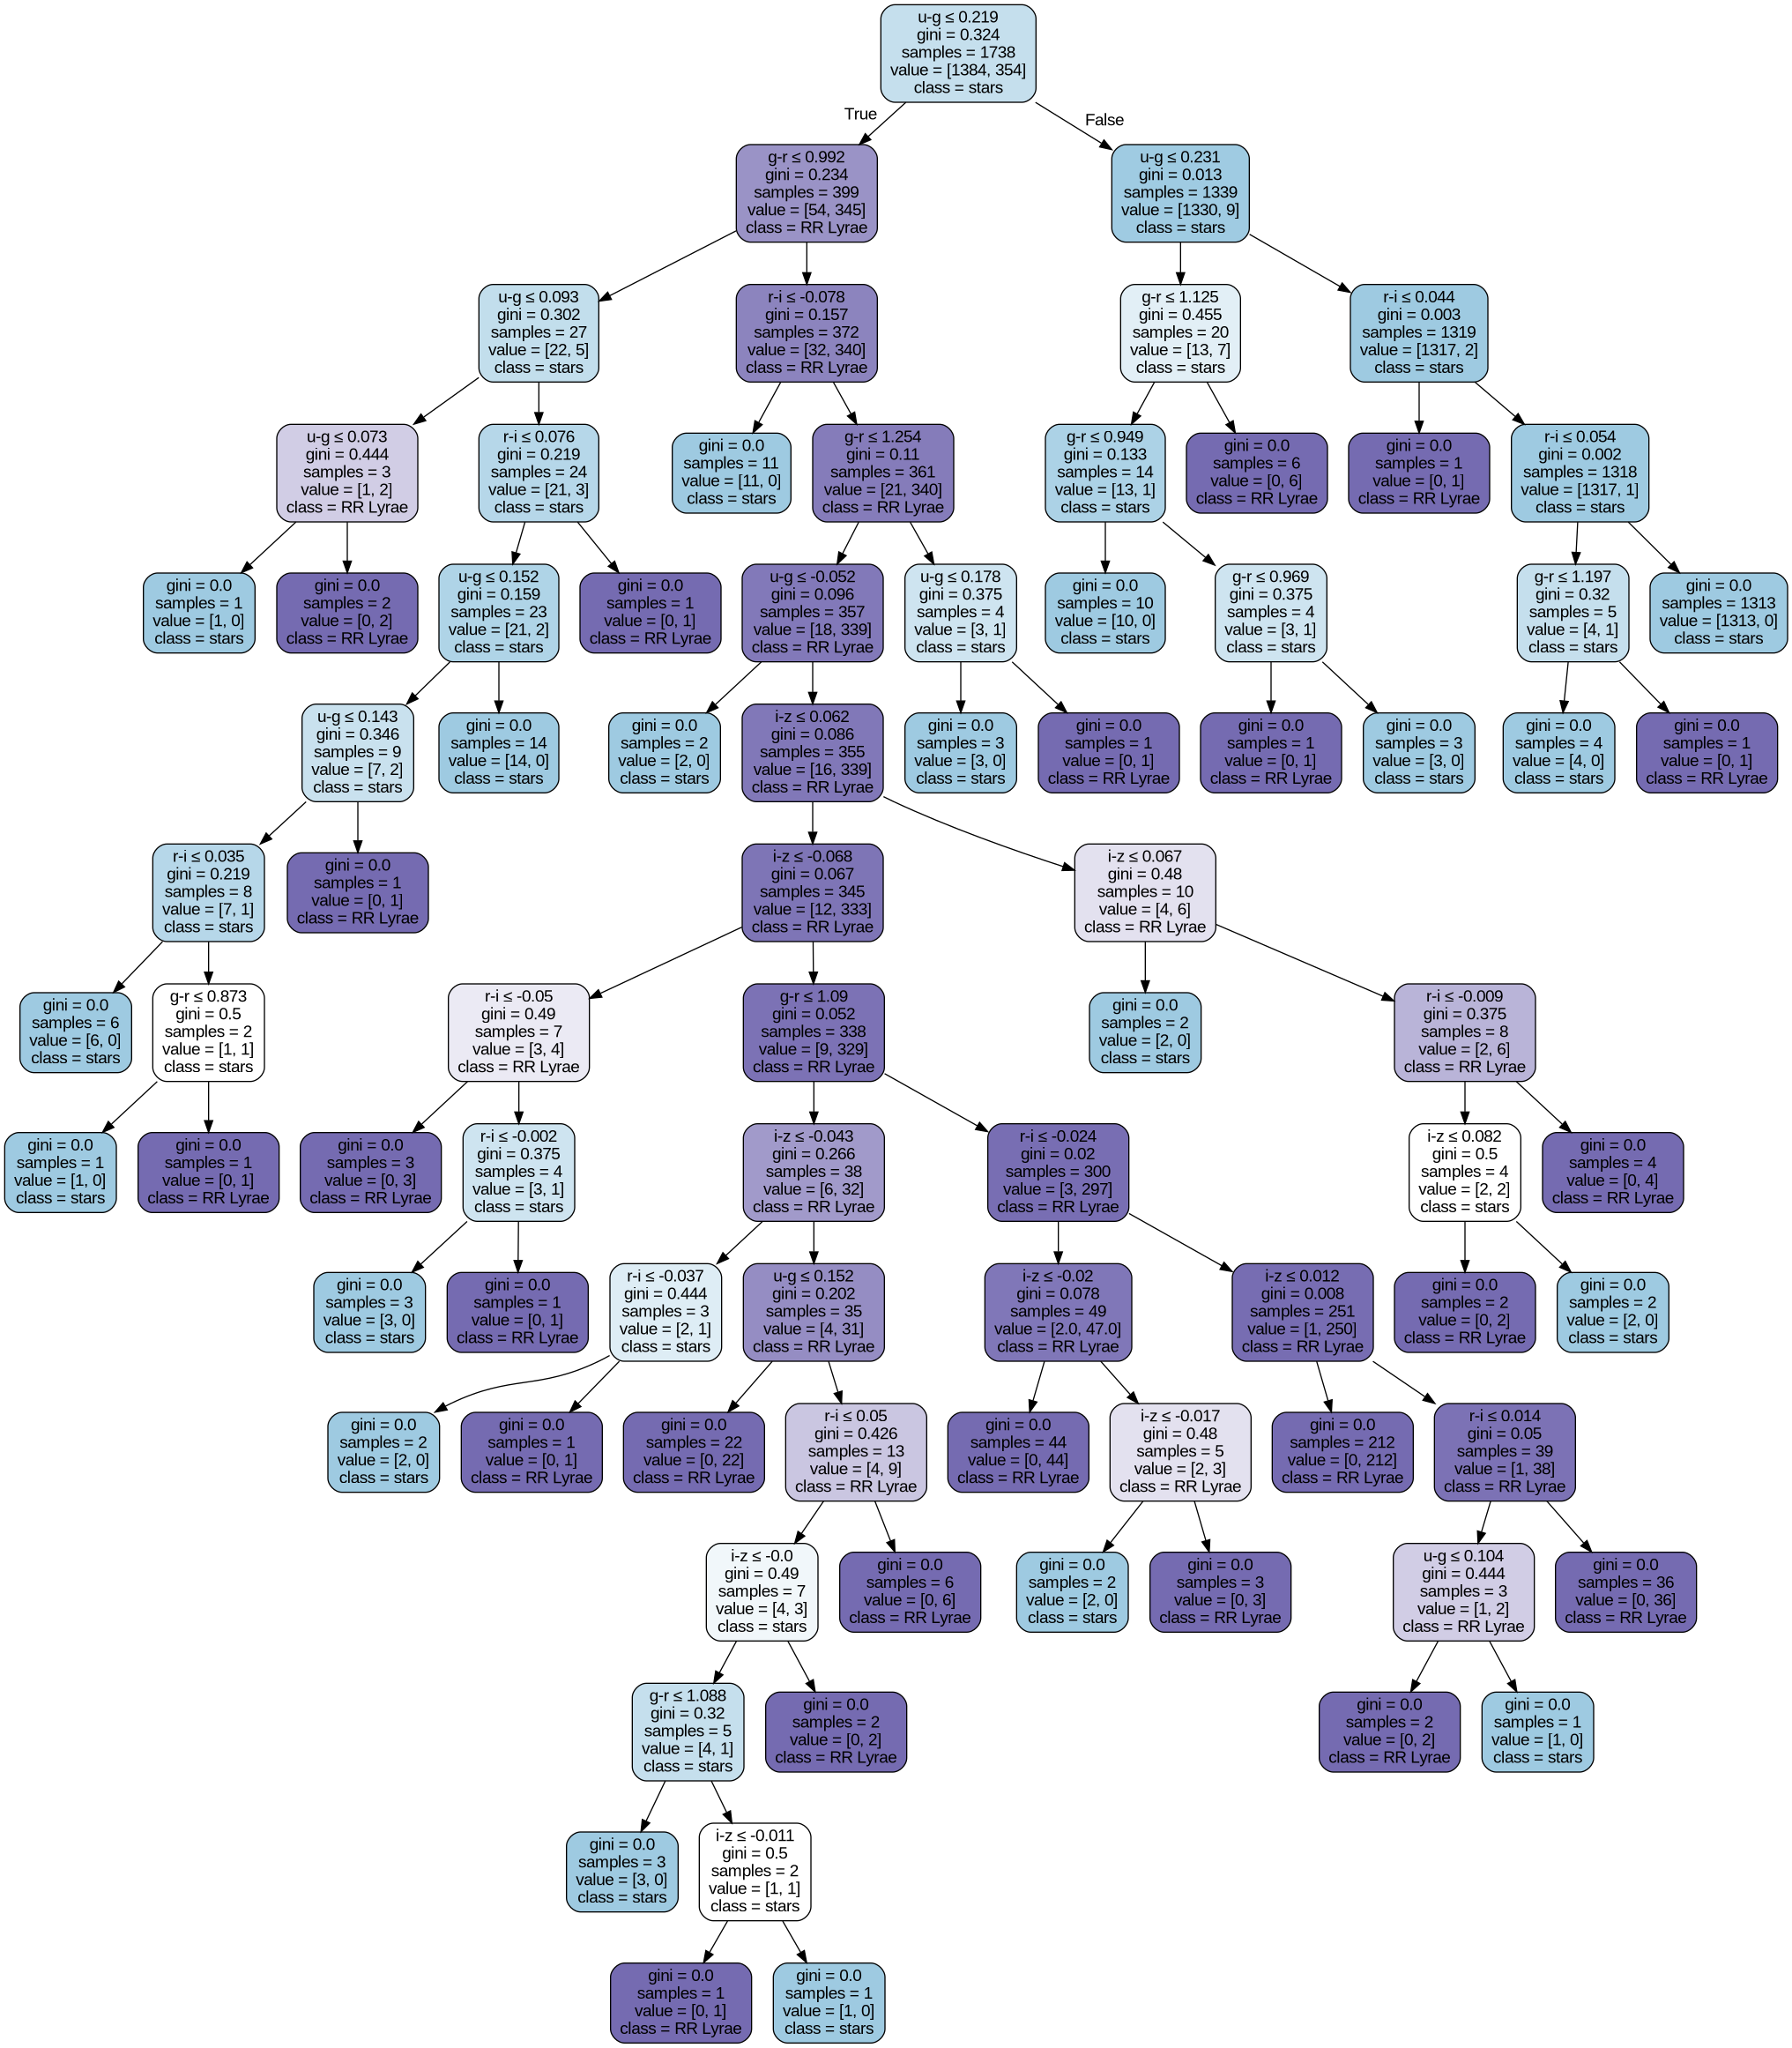

In [74]:
# Recordatorio: Las características siempre se permutan aleatoriamente en cada división.
# Por lo tanto, la mejor división encontrada puede variar, incluso con los mismos datos
# de entrenamiento y max_features=n_features, si la mejora del criterio es idéntica
# para varias divisiones enumeradas durante la búsqueda de la mejor división.
# Para obtener un comportamiento determinista durante el ajuste, random_state debe estar fijo.

dot_data = StringIO()

export_graphviz(
    model_tree,
    out_file=dot_data,
    feature_names=['u-g', 'g-r', 'r-i', 'i-z'],
    class_names=['stars', 'RR Lyrae'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label() and 'value = [' in node.get_label():

        values = [float(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [int(255 * v / sum(values)) for v in values]

        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha)
            color = '#9ecae1' + str(alpha)   # turquesa
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#756bb1' + str(alpha)   # magenta

        node.set_fillcolor(color)

Image(graph.create_png())

### Preguntas

Observe la estructura del árbol y responda brevemente:

1. ¿El árbol parece muy simple o bastante complejo? Justifique a partir del número de niveles o divisiones.
2. ¿Qué desventaja podría tener un árbol demasiado grande en un problema como este?

1. El árbol es bastante complejo. Tiene 14 niveles de profundidad y 42 hojas.
2. Un árbol tan grande corre riesgo de sobreajustar los datos (overfitting): memoriza particularidades el set de entrenamiento, en vez de aprender el patrón/tendencia general de los datos.

#### Miremos las métricas accuracy para set de entrenamiento y prueba

In [75]:
print(metrics.accuracy_score(y_train, model_tree.predict(X_train))) #train score

print(metrics.accuracy_score(y_test, model_tree.predict(X_test))) #test score

1.0
0.9651006711409396


#### Otras métricas

In [76]:
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall   :", metrics.recall_score(y_test, y_pred))
print("F1-score :", metrics.f1_score(y_test, y_pred))

Precision: 0.8759124087591241
Recall   : 0.9302325581395349
F1-score : 0.9022556390977443


In [77]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[599,  17],
       [  9, 120]])

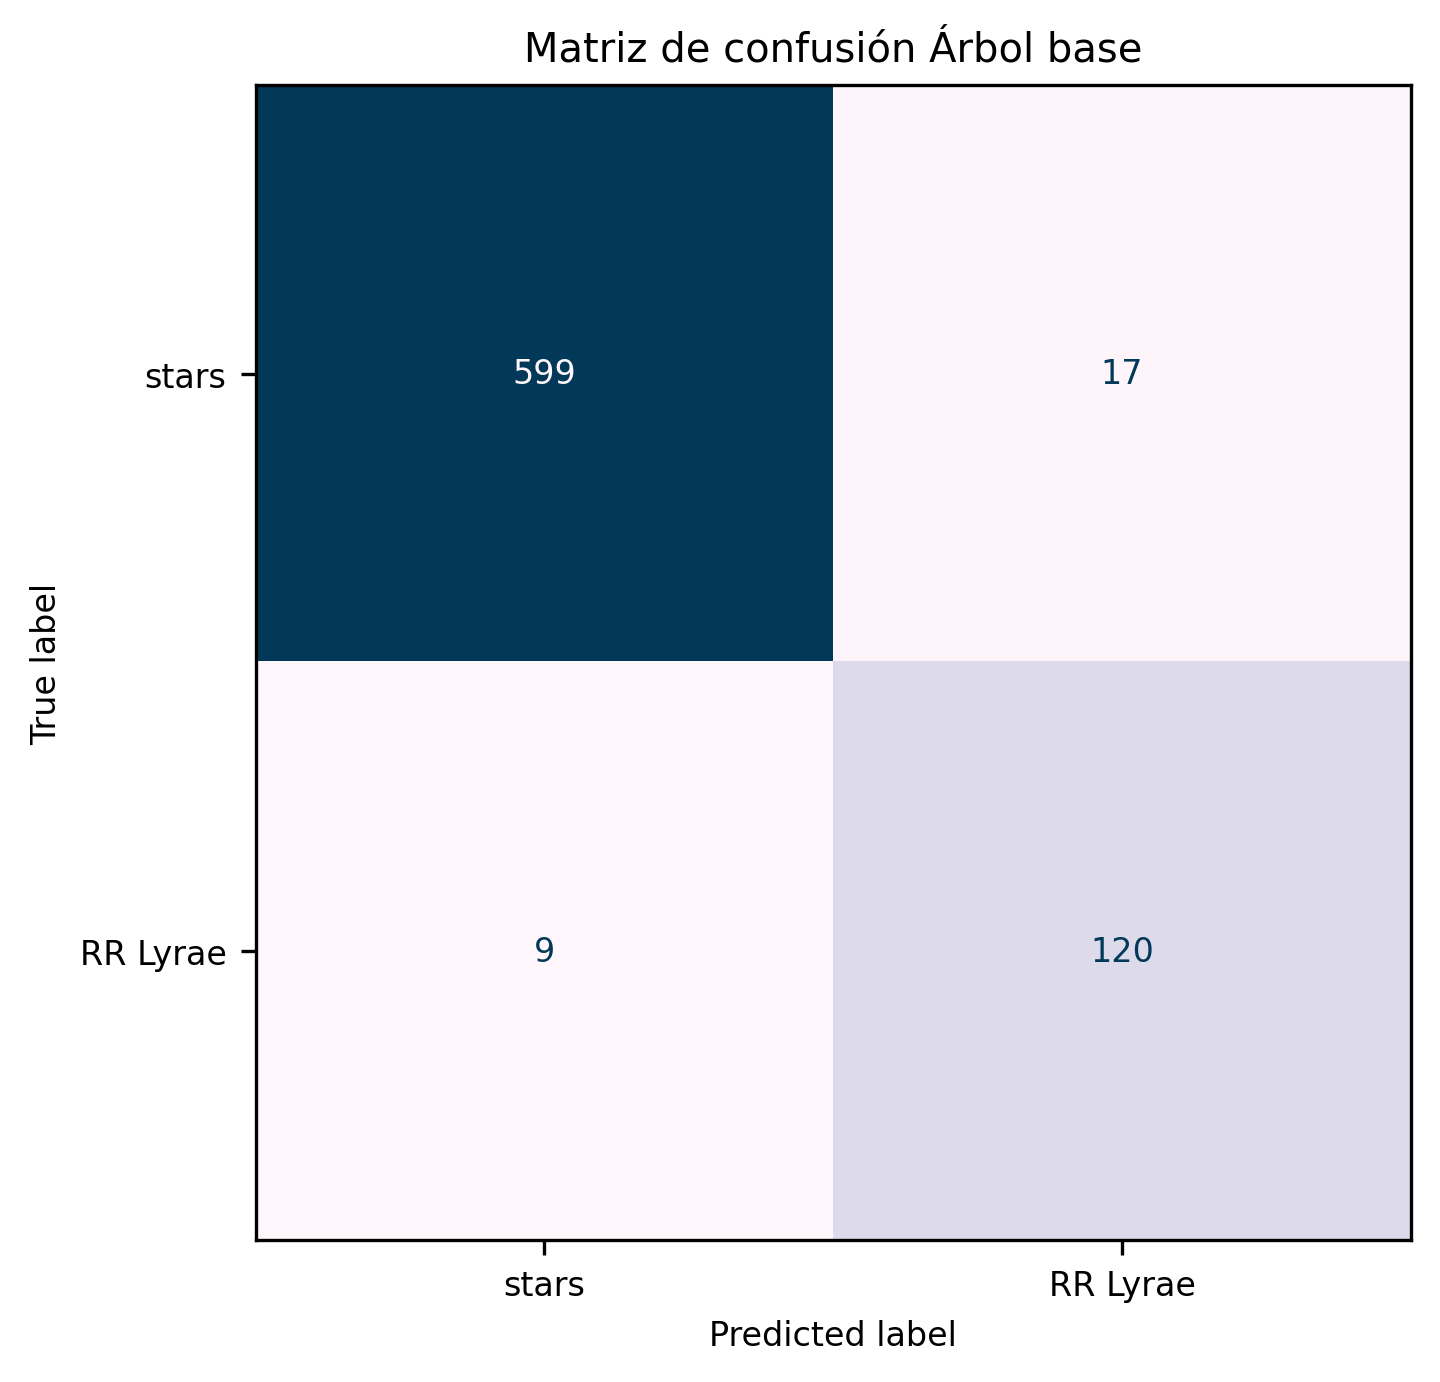

In [78]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["stars", "RR Lyrae"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de confusión Árbol base")
plt.show()

#### A partir de la matriz de confusión obtenida:
1.  Identifique los valores de:
   - verdaderos positivos (TP)
   - verdaderos negativos (TN)
   - falsos positivos (FP)
   - falsos negativos (FN)
2. Calcule las métricas "a mano"



verdadero positivo (cuando el predicted label y el true label de RR Lyrae coinciden)=120

verdadero negativo (cuando el predicted label y el true label de stars coinciden)=599

false positive (cuando se interpreta un dato como RR Lyrea cuando en realidad es un star)=17

false negative (cuando se interpreta un dato star como uno RR Lyrae)=9

In [79]:
tn, fp, fn, tp = cm.ravel()
print("TN:", tn, "FP:", fp, "FN:", fn, "TP:", tp)

TN: 599 FP: 17 FN: 9 TP: 120


In [80]:
precision_manual = tp / (tp + fp) #verdaderos positivos identificables sobre todos los positivos identificados
recall_manual = tp / (tp + fn)   #verdaderos positivos sobre todos los datos reales (se le agregarn los datos miscalificados)
f1_manual = 2 * precision_manual * recall_manual / (precision_manual + recall_manual)
accuracy_manual = (tp + tn) / (tp + tn + fp + fn) #datos verdaderos (identificados de manera correcta) sobre la totalidad de los datos

print("Precision (manual):", precision_manual)
print("Recall (manual):", recall_manual)
print("F1 (manual):", f1_manual)
print("Accuracy (manual):", accuracy_manual)

Precision (manual): 0.8759124087591241
Recall (manual): 0.9302325581395349
F1 (manual): 0.9022556390977443
Accuracy (manual): 0.9651006711409396


### Preguntas
1. Explique con sus palabras qué significa, en este problema:
   - un falso positivo
   - un falso negativo

2. Si el objetivo científico fuera encontrar la mayor cantidad posible de RR Lyrae, ¿qué tipo de error preocuparía más?

3. Si el objetivo fuera construir una muestra final más limpia, ¿qué tipo de error preocuparía más?

Falso positivo: una estrella normal que el modelo clasifica erróneamente como RR Lyrae.
Falso negativo: una RR Lyrae real que el modelo la clasifica como stars.

Si el objetivo es encontrar la mayor cantidad posible de RR Lyrae (maximizamos detecciones), lo que deberiamos minimizar son los falsos negativos. En ese caso interesa maximizar el RECALL, aunque eso significa tener más falsos positivos.

Si el objetivo es construir una muestra final más limpia, me preocuparía mas en los FALSOS POSITIVOS (contaminar la muestra con estrellas normales). En ese caso maximizamos la PRECISION.

#### Todo parece funcionar bien, pero sólo hicimos un split. Necesitamos que el resultados sea robusto. Para esto, implementaremos Cross-validation usando [k-fold](https://scikit--learn-org.translate.goog/stable/modules/generated/sklearn.model_selection.KFold.html?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc)

In [81]:
# Esta es la versión estándar. Importante: no baraja los datos, por lo que si tus
# ejemplos positivos están todos al principio o al final, podría llevar a resultados
# desastrosos.

cv1 = KFold(n_splits = 5)

#Esta es la versión 2: se ha añadido el barajado (¡recomendado!)

cv2 = KFold(shuffle = True, n_splits = 5, random_state=5)

# LA ESTRATIFICACIÓN asegura que las distribuciones de clases en cada división se
# asemejen a las del conjunto de datos completo.

cv3 = StratifiedKFold(shuffle = True, n_splits = 5, random_state=5)


In [87]:
#el codigo no me reconocia las variables y_cv2 o y_cv3 asi que las tuve que definir

model1 = DecisionTreeClassifier(random_state=3)
y_cv3 = cross_val_predict(model1, X, y, cv=cv3)

model2 = DecisionTreeClassifier(random_state=3)
y_cv2 = cross_val_predict(model2, X, y, cv=cv2)

### Efecto de la estratificación: veamos el conteo de clases en cada conjunto de divisiones.

In [88]:
cv1.split(X, y)

<generator object _BaseKFold.split at 0x7d895ba78ae0>

In [89]:
for train, test in cv1.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1504  483]   |   test -  [496]
train -  [1987]   |   test -  [ 13 483]


In [90]:
for train, test in cv2.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1610  376]   |   test -  [390 107]
train -  [1587  399]   |   test -  [413  84]
train -  [1599  388]   |   test -  [401  95]
train -  [1604  383]   |   test -  [396 100]


In [91]:
for train, test in cv3.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  387]   |   test -  [400  96]
train -  [1600  387]   |   test -  [400  96]


In [101]:
# HECHO CON IA SOLO PARA VISUALIZAR Y ORDENAR DATOS!!!!
#Comparación: y_cv2 (KFold barajado) vs y_cv3 (StratifiedKFold)
print("Diferencias en predicciones:", np.sum(y_cv3 != y_cv2))
print("Matriz de confusión (KFold barajado):\n", metrics.confusion_matrix(targets, y_cv2))
print("Matriz de confusión (StratifiedKFold):\n", metrics.confusion_matrix(targets, y_cv3))
# Ambos esquemas dan resultados parecidos porque el barajado ya evita el problema principal
# (folds con una sola clase), pero StratifiedKFold sigue siendo la opción más segura porque
# garantiza explícitamente la misma proporción de clases en cada fold.

Diferencias en predicciones: 52
Matriz de confusión (KFold barajado):
 [[1955   45]
 [  43  440]]
Matriz de confusión (StratifiedKFold):
 [[1955   45]
 [  33  450]]


### La función [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate) proporciona los puntajes (especificados por el parámetro de evaluación elegido), en forma de diccionario.

In [102]:
scores1 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv1, scoring = 'accuracy')

scores2 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv2, scoring = 'accuracy')

scores3 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv3, scoring = 'accuracy')

In [103]:
scores3

{'fit_time': array([0.00702953, 0.00594926, 0.00690103, 0.0067687 , 0.00614023]),
 'score_time': array([0.00242972, 0.00224233, 0.00224018, 0.00224066, 0.00216627]),
 'test_score': array([0.97987928, 0.96579477, 0.96579477, 0.98185484, 0.95766129])}

Solo nos interesa el 'test_score'

#### Calculamos el promedio y $\sigma$

In [104]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))

0.785 0.380


In [105]:
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))

0.965 0.014


In [106]:
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

0.970 0.009


La validación cruzada sin barajar (`cv1`) produce un resultado muy inestable, con una desviación estándar extremadamente alta. Esto ocurre porque los datos están ordenados por clase, de modo que algunos folds no representan bien el problema completo.

Al activar el barajado (`cv2`), el rendimiento mejora drásticamente y la dispersión disminuye. Sin embargo, el método que resulta más apropiado para este problema es `StratifiedKFold` (`cv3`), ya que además de mezclar los datos, conserva aproximadamente la proporción de clases en cada fold.

En problemas de clasificación desbalanceada, esta última estrategia suele ser la más recomendable.

In [107]:
scores1 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv1, scoring = 'recall')

scores2 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv2, scoring = 'recall')

scores3 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv3, scoring = 'recall')

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricW

In [108]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

nan nan
0.903 0.016
0.925 0.019


### ¿Por qué aparece este warning?

En algunos folds generados por `KFold` sin barajado, el conjunto de prueba contiene solo ejemplos de una clase. En ese caso, el recall de la clase positiva (RR Lyrae) no puede calcularse, porque no hay positivos reales en ese fold.

Esto muestra que una estrategia de partición inadecuada puede hacer que la evaluación sea inestable, engañosa o incluso inválida.

#### También extraeremos los train scores, que nos servirán cuando estemos diagnosticando el modelo a través de bias vs variance.¶

In [109]:
scores1 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv1, scoring = 'recall', \
                         return_train_score = True)

scores2 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv2, scoring = 'recall', \
                         return_train_score = True)

scores3 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv3, scoring = 'recall',
                         return_train_score = True)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricW

In [110]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['train_score'].mean()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['train_score'].mean()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['train_score'].mean()))

nan nan
0.917 1.000
0.925 1.000


### La función  `cross_validate` es útil para calcular el puntaje, pero no produce etiquetas predichas.

#### Estas pueden obtenerse utilizando la función [`cross_val_predict`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html), que guarda las predicciones para cada uno de los k-folds de prueba y las compila juntas.


In [111]:
model1 = DecisionTreeClassifier(random_state = 3)

y_cv3 = cross_val_predict(model1, X,y, cv = cv3)
# Estas son las predicciones,
# y son independientes del parámetro de evaluación

In [112]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

### Sin embargo, las cosas pueden cambiar si uso un esquema de validación cruzada diferente:

In [113]:
model2 = DecisionTreeClassifier(random_state = 3)

y_cv2 = cross_val_predict(model2, X,y, cv = cv2)

In [114]:
np.sum(y_cv3-y_cv2)

np.int64(10)

In [115]:
np.sum(y_cv2)

np.int64(485)

In [116]:
np.sum(y_cv3 != y_cv2) #comparando las predicciones

np.int64(52)

In [117]:
metrics.confusion_matrix(targets,y_cv2)

array([[1955,   45],
       [  43,  440]])

In [118]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

In [123]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(0.2, 1.0, 5), scoring = 'accuracy'):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure(figsize=(10,6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel(str(scoring))

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring, shuffle=True, random_state=42)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from cross-validation")

    plt.legend(loc="best")
    return plt

In [121]:
model = DecisionTreeClassifier(random_state = 5)

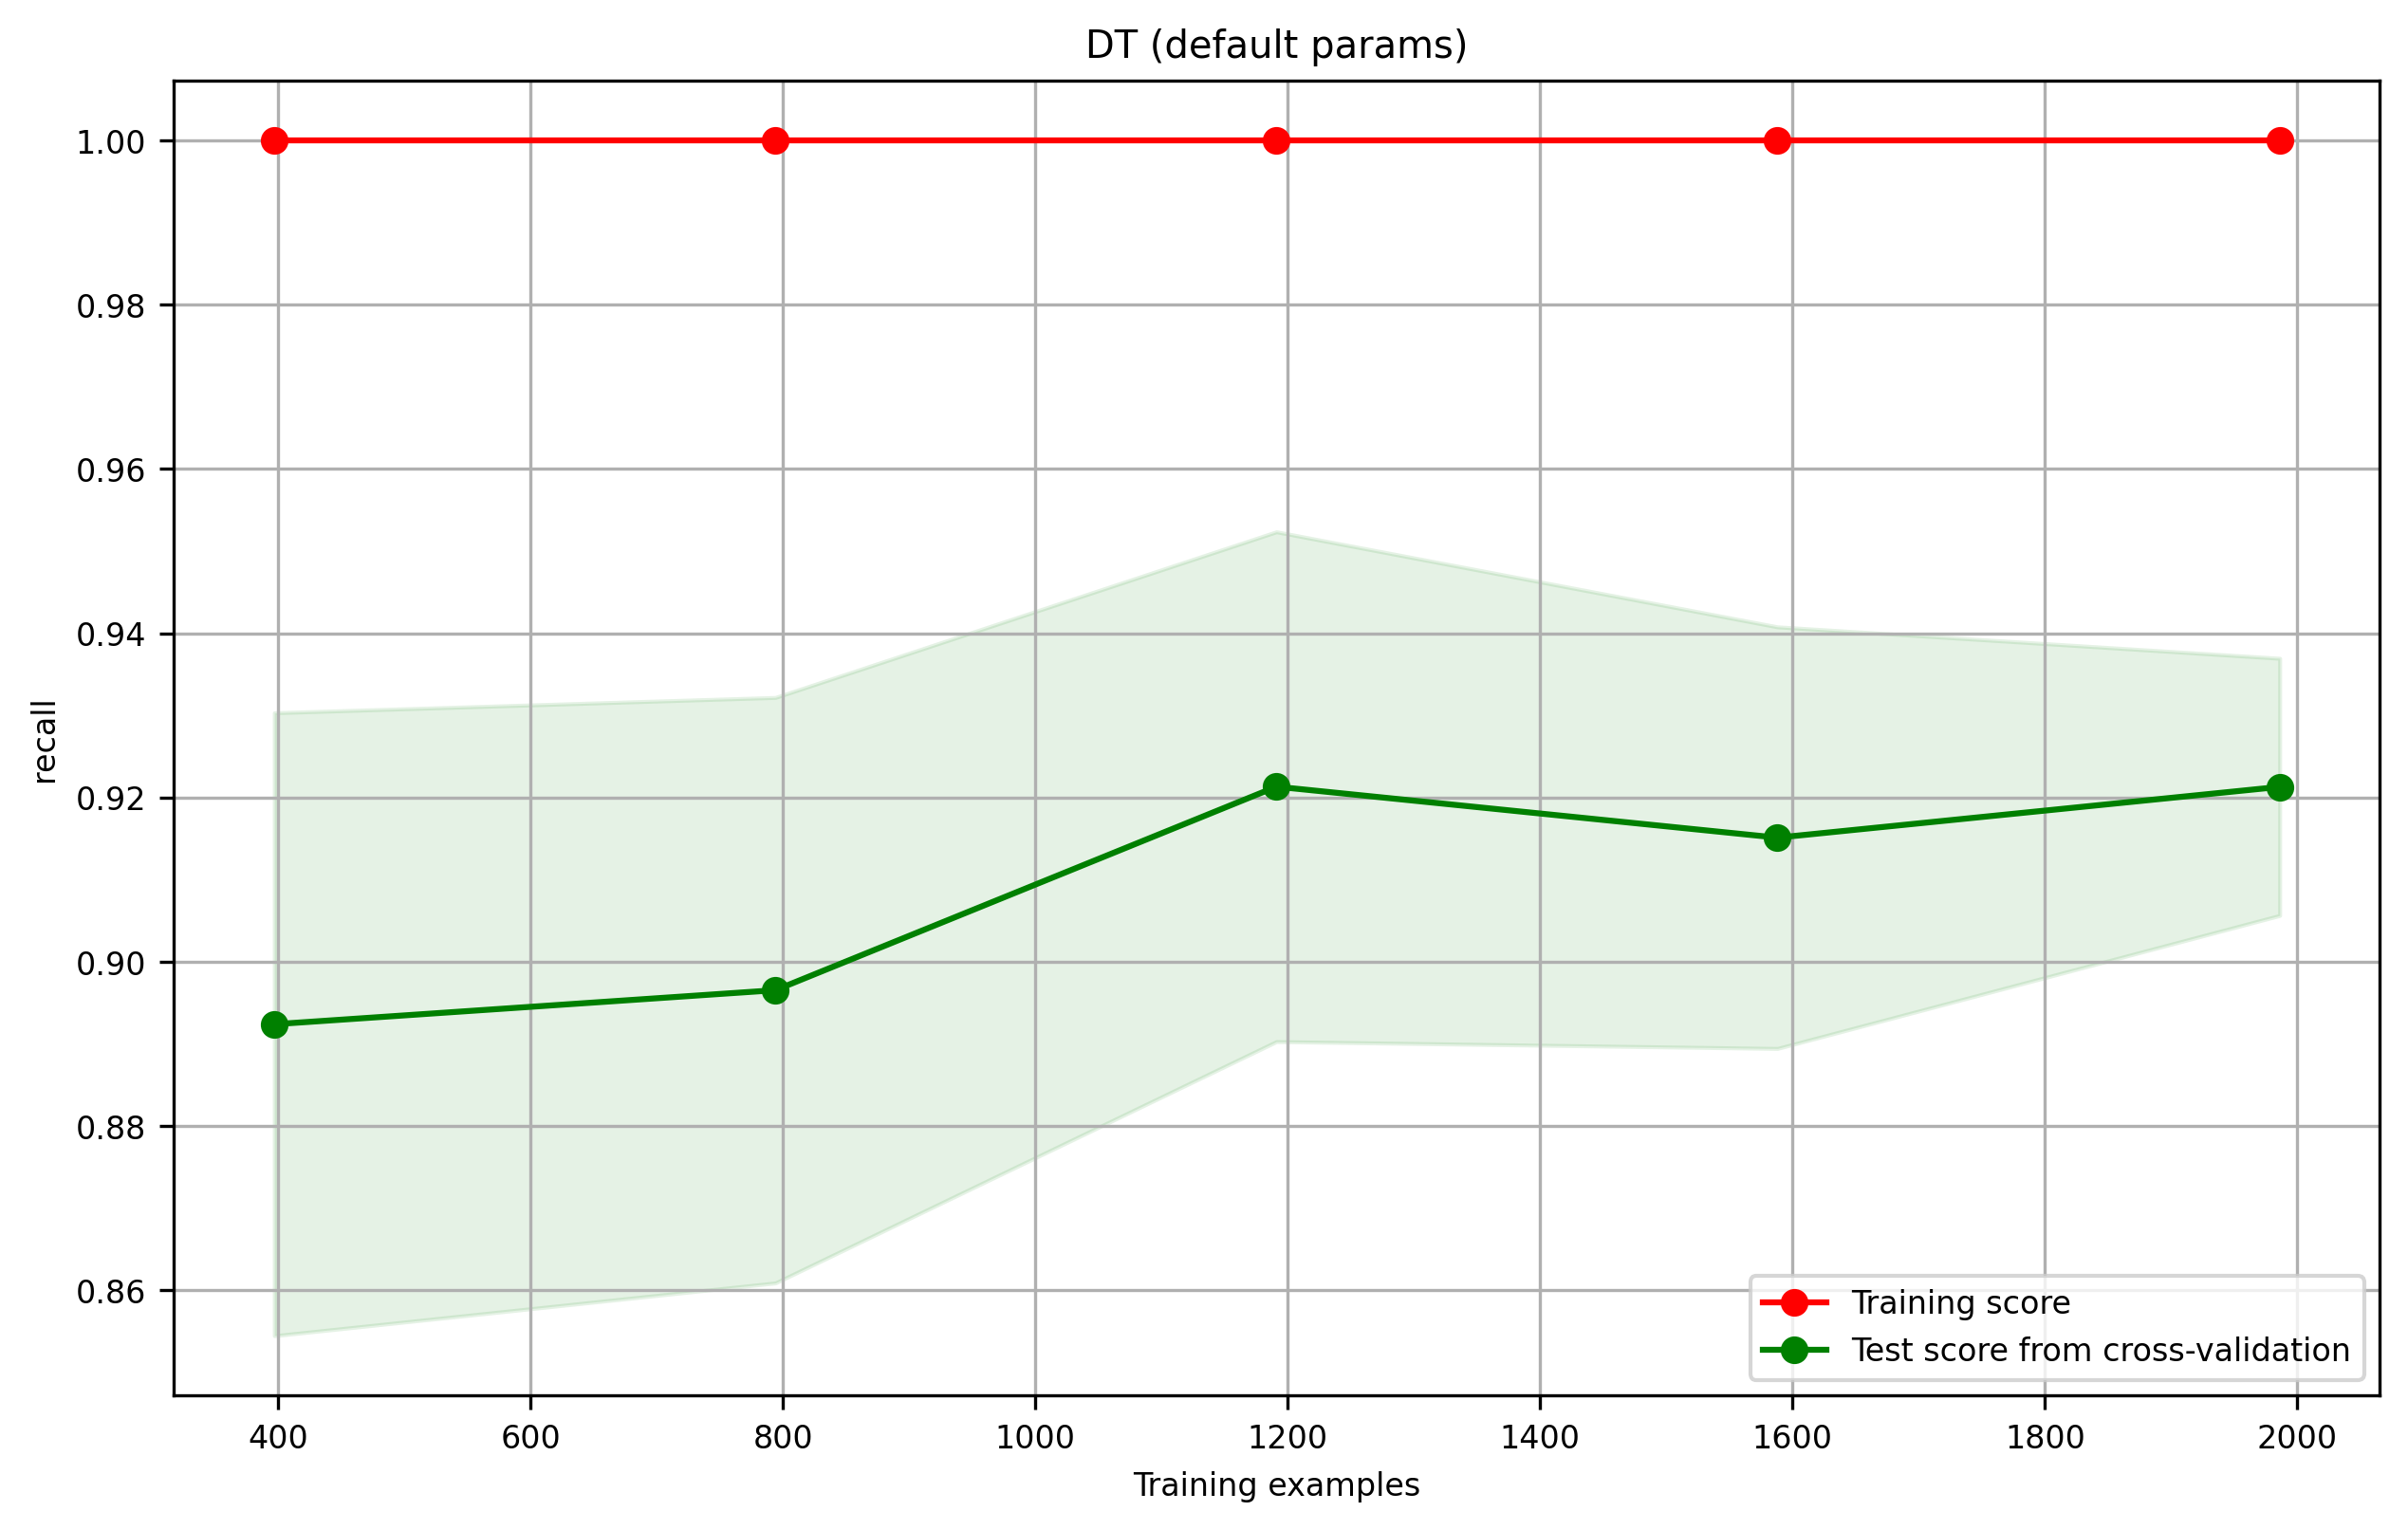

In [124]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'recall');

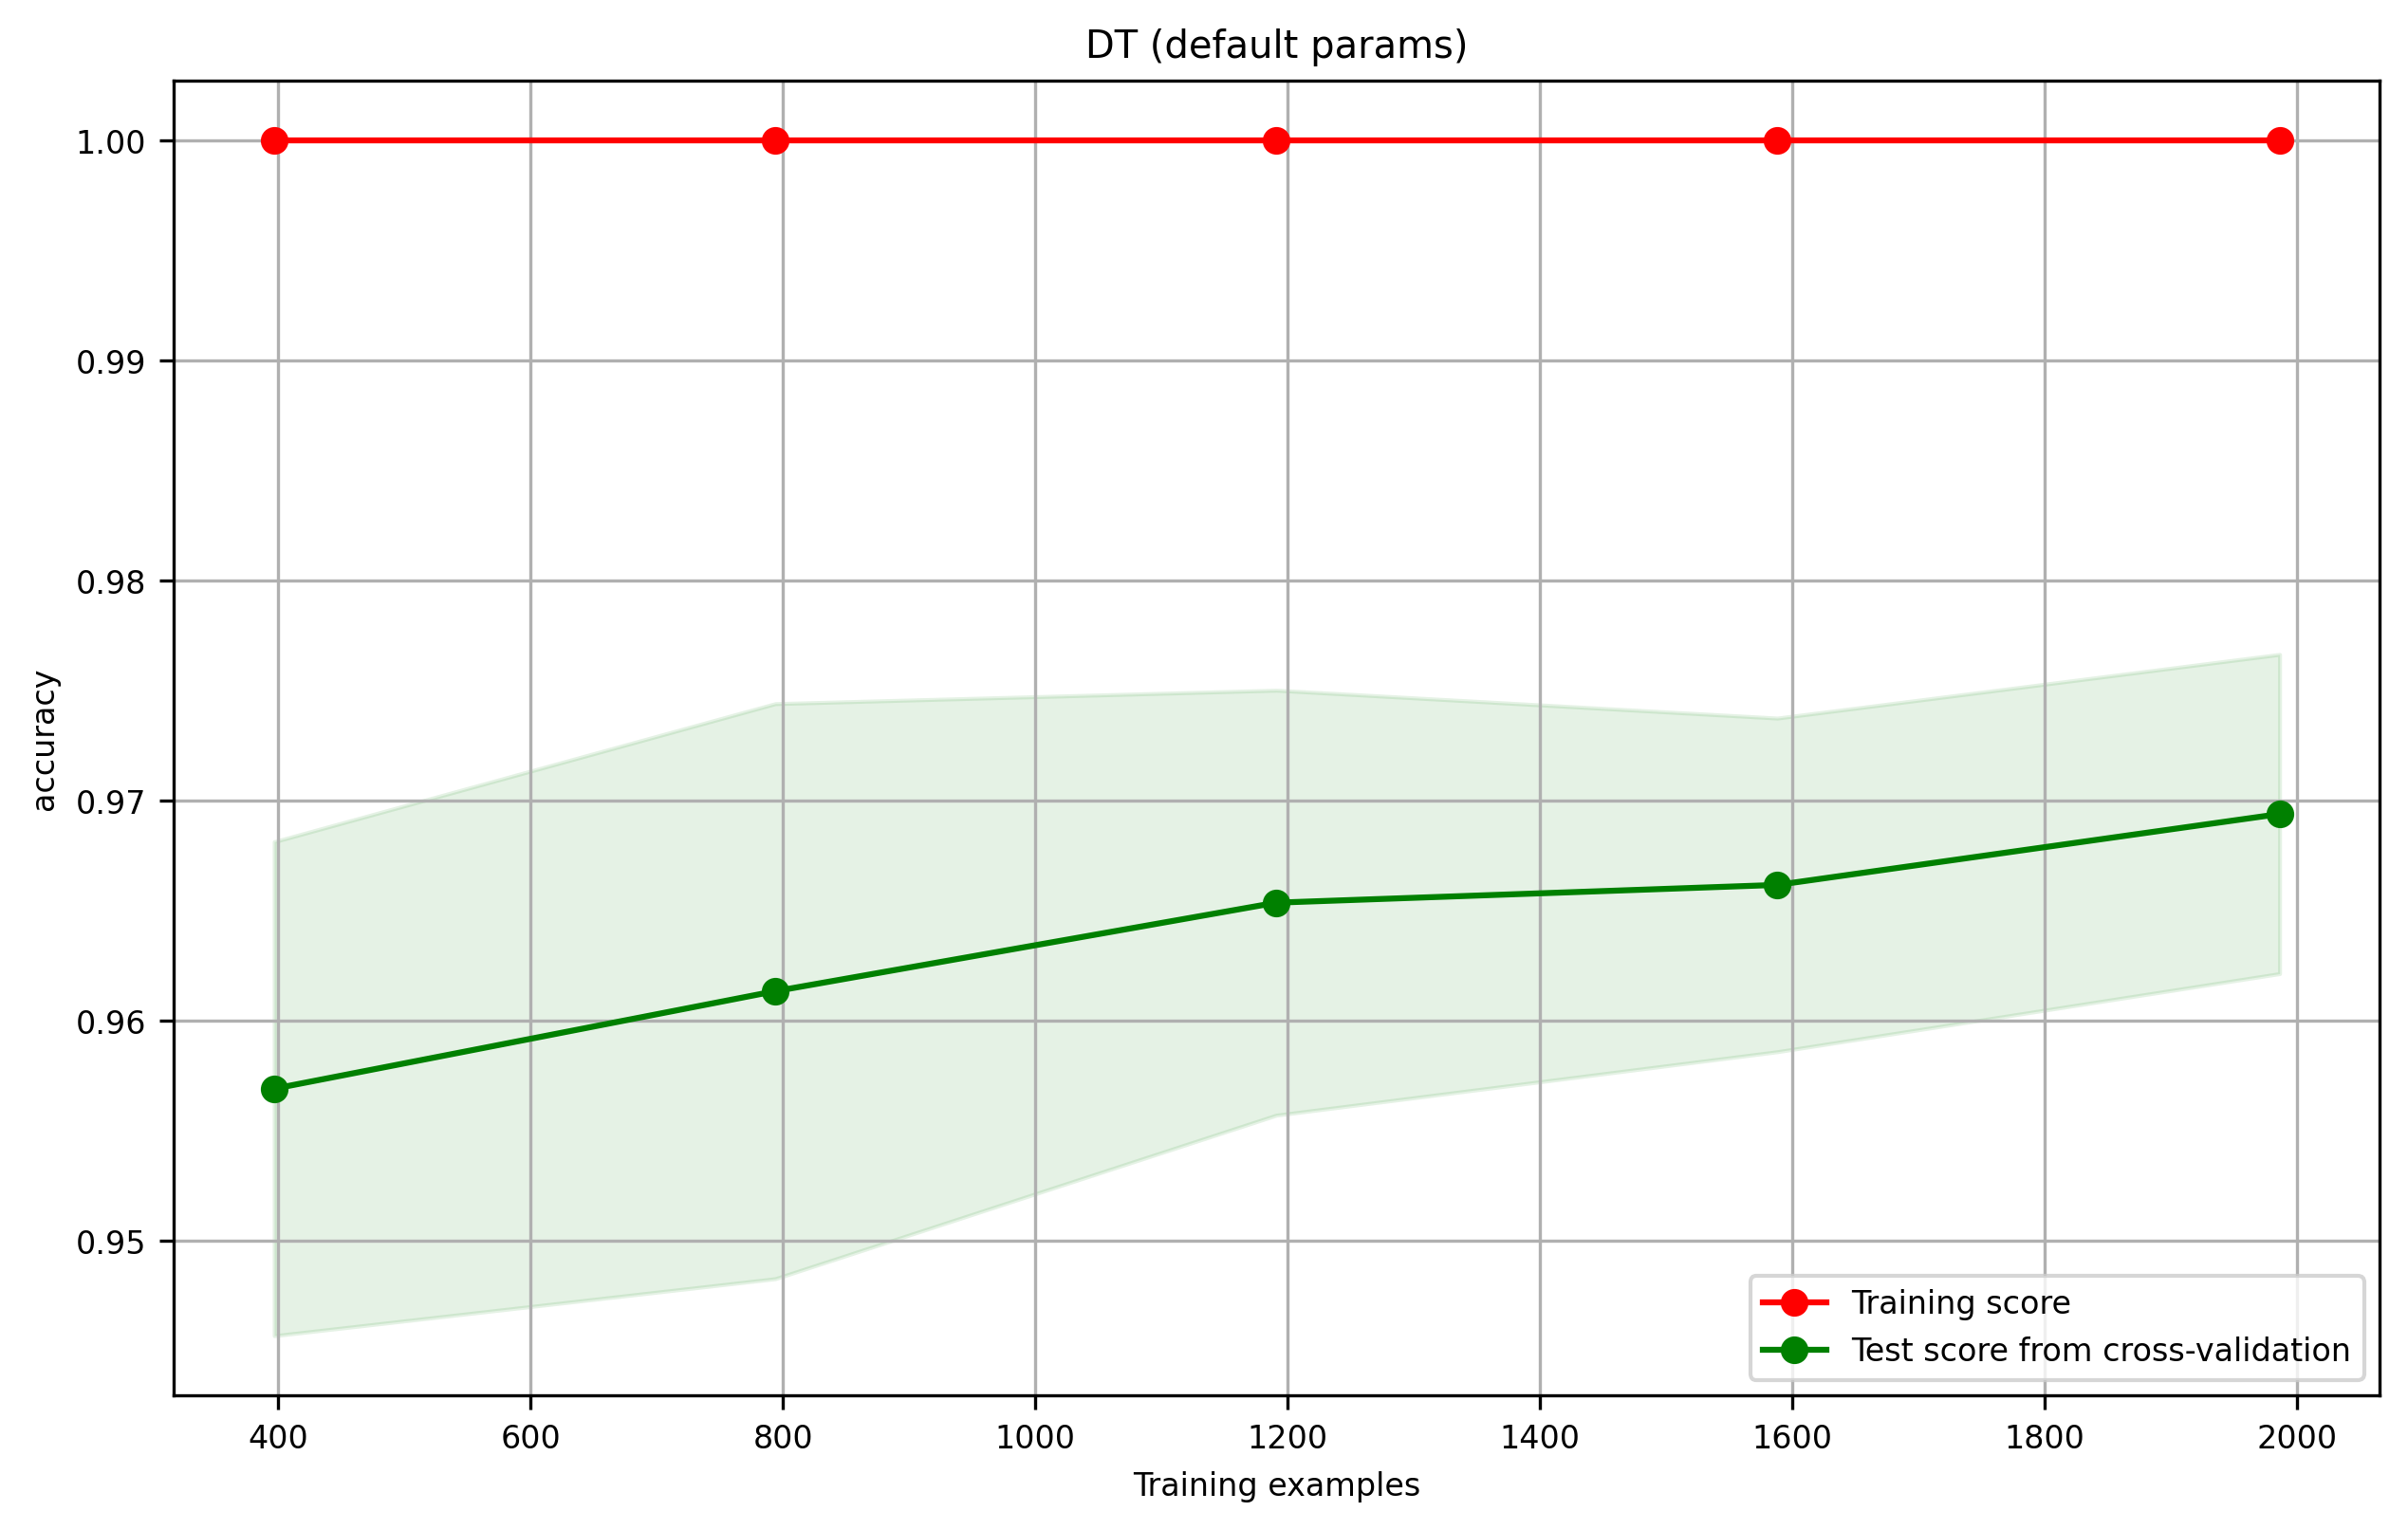

In [125]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'accuracy');

### **Preguntas**

Responda brevemente:

1. ¿Existe una brecha entre la curva de entrenamiento y la de validación? ¿Qué sugiere eso?
2. ¿El rendimiento de validación mejora al agregar más ejemplos?
3. ¿Hablaría aquí de alto sesgo, alta varianza o sobreajuste moderado? Justifique.
4. Escriba una conclusión general sobre el comportamiento del árbol base a partir de estas curvas.

1. El hecho de que exista una brecha en la curva de entrenatiento y la de validación sugiere que el modelo se ajusta a los datos de entrenamiento, pero no logra no tiene los mismos resultados en datos que no haya visto, lo que es un signo de overfitting

2. El rendimiento de de la validación mejora al aumentar los ejemplos, pero no logra a coincidir con la curva de entrenamiento.

3. Se genera un sobre ajuste de los datos. Puede memorizar bien el set de entrenamiento, pero no logra generalizar su ajuste, que es consistente con tener un arbol complejo y con muchos niveles.

4. El árbol base es demasiado flexible, por lo que genera un overfitting de los datos. si se limita su complejidad y hacemos que tenga menos niveles y hojas, podría mejorar la capacidad de generalización

### Desafío: ¿un árbol más simple generaliza mejor?

Entrene ahora un segundo árbol, más restringido que el árbol base. Por ejemplo, puede probar con:

- `max_depth=3`, o
- `min_samples_leaf=10`

Luego compare su rendimiento con el árbol base usando:

- accuracy
- precision
- recall
- F1-score



Arbol inicial
train acc: 1.0
test acc: 0.9651006711409396
precision: 0.8759124087591241
recall: 0.9302325581395349
f1: 0.9022556390977443
Arbol simplificado
train acc: 0.9844649021864211
test acc: 0.9731543624161074
precision: 0.9037037037037037
recall: 0.9457364341085271
f1: 0.9242424242424242
accuracy: base=0.971  simple=0.977
precision: base=0.920  simple=0.925
recall: base=0.932  simple=0.961
f1: base=0.926  simple=0.942


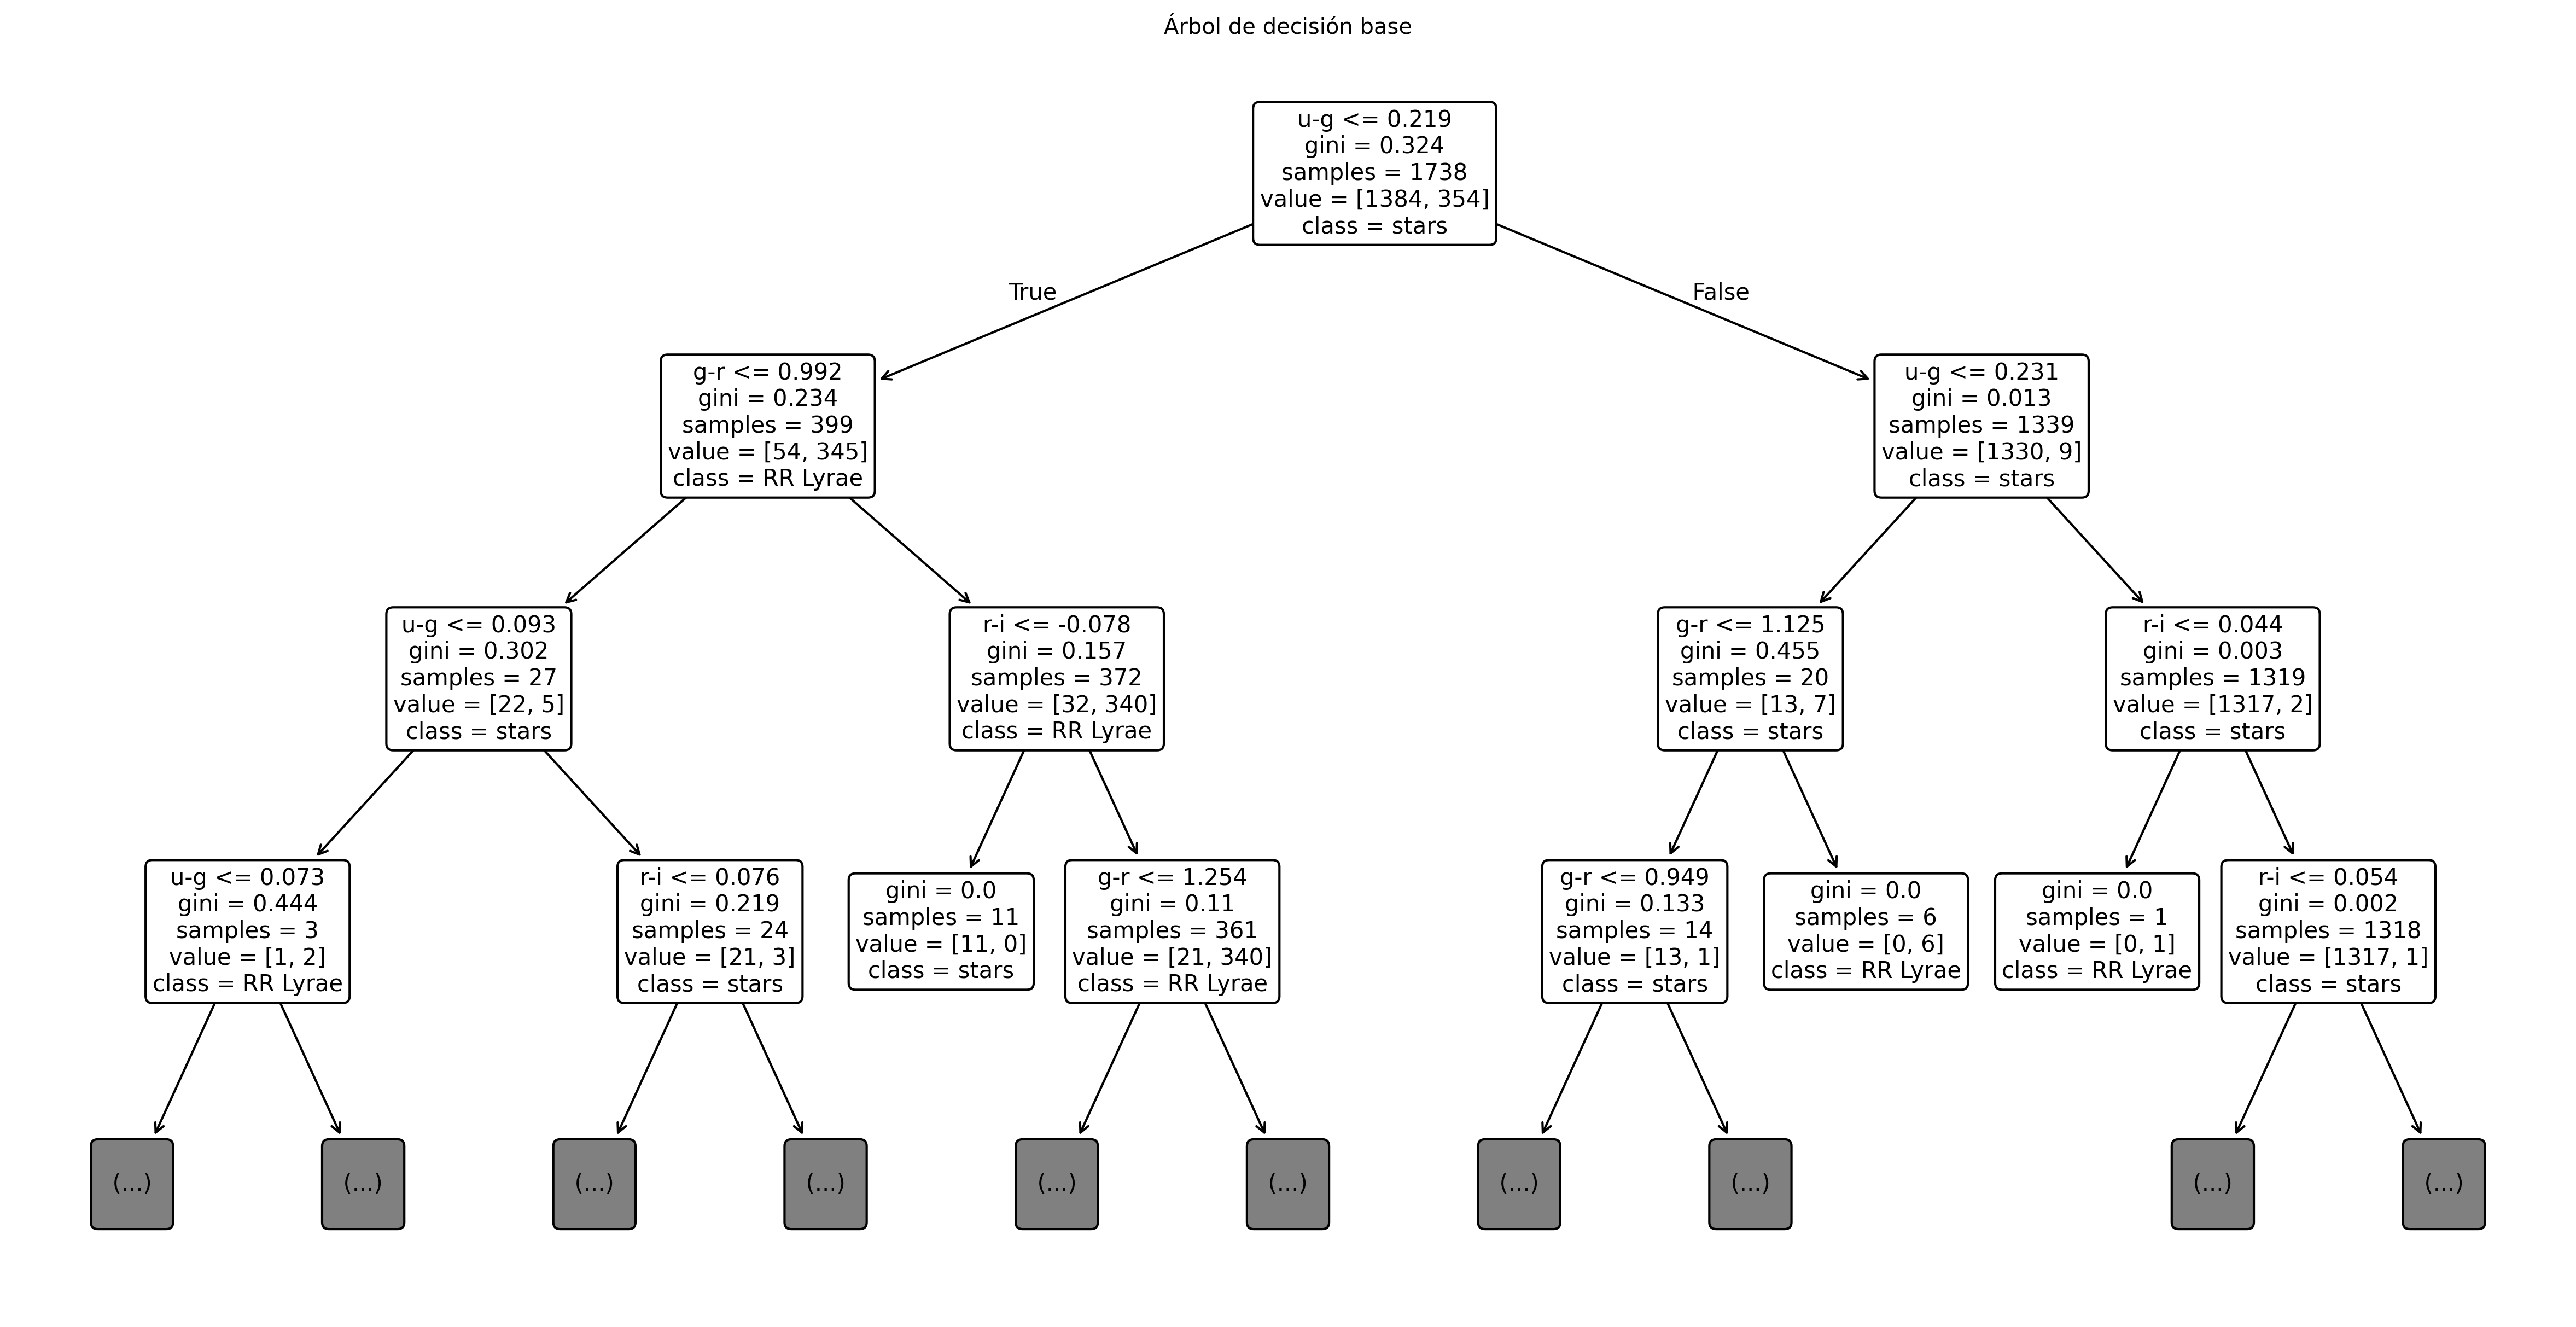

In [128]:
model_tree_simple = DecisionTreeClassifier(random_state=42, max_depth=3)
model_tree_simple.fit(X_train, y_train)
y_pred_simple = model_tree_simple.predict(X_test)

#escribimos todos los prints juntos para train y test de los arboles, las metricas

print("Arbol inicial")
print("train acc:", metrics.accuracy_score(y_train, model_tree.predict(X_train)))
print("test acc:", metrics.accuracy_score(y_test, y_pred))
print("precision:", metrics.precision_score(y_test, y_pred))
print("recall:", metrics.recall_score(y_test, y_pred))
print("f1:", metrics.f1_score(y_test, y_pred))

print("Arbol simplificado")
print("train acc:", metrics.accuracy_score(y_train, model_tree_simple.predict(X_train)))
print("test acc:", metrics.accuracy_score(y_test, y_pred_simple))
print("precision:", metrics.precision_score(y_test, y_pred_simple))
print("recall:", metrics.recall_score(y_test, y_pred_simple))
print("f1:", metrics.f1_score(y_test, y_pred_simple))


# Hacemos un ciclo for para poder hacer el cross validate de las metricas de los arboles inicial y simplificado y poder compararlos

for scoring in ['accuracy','precision','recall','f1']:
    s_base = cross_validate(DecisionTreeClassifier(random_state=42), X, y, cv=cv3, scoring=scoring)
    s_simple = cross_validate(DecisionTreeClassifier(random_state=42, max_depth=3), X, y, cv=cv3, scoring=scoring)
    print(f"{scoring}: base={s_base['test_score'].mean():.3f}  simple={s_simple['test_score'].mean():.3f}")


plt.figure(figsize=(20,10))

plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=["stars", "RR Lyrae"],
    filled=False,
    rounded=True,
    max_depth=3,
    fontsize=10
)

plt.title("Árbol de decisión base")
plt.show()

### Preguntas

A partir de los resultados obtenidos con validación cruzada:

1. ¿Qué ocurrió con el rendimiento al restringir la complejidad del árbol?
2. ¿El árbol más simple empeoró o mejoró la generalización?
3. ¿Qué sugieren estos resultados sobre el árbol base?
4. En este problema, ¿parece conveniente usar el árbol sin restricciones?
5. ¿Qué métrica le parece más importante para decidir entre ambos modelos?

1. Mejoró en las cuatro métricas evaluadas con validación cruzada, a pesar de que el árbol simple tiene menor accuracy en el set de entrenamiento

2. Mejoró la generalización: aunque memoriza un poco menos el entrenamiento, predice mejor en datos no antes vistos, ya que tiene mayor recall y F1 en cross-validation

3. Que el árbol base estaba sobreajustado: su alto accuracy de entrenamiento nos decía que había memorizado ruido/errores específico de esos datos.

4. No. El árbol simplificado (max_depth=3) es preferible: es más simple y generaliza mejor según validación cruzada.

5. En este problema, el recall es relevante porque queremos minimizar RR Lyrae no detectadas. El F1-score es útil porque resume precision y recall en un solo número, y para ambas metricas el árbol simple es mejor.

## Desafío: comparar con kNN

Hasta ahora trabajamos con árboles de decisión. Ahora comparemos ese enfoque con un clasificador distinto: **k-Nearest Neighbors (kNN)**.

Entrene un modelo kNN y compárelo con el árbol simple usando validación cruzada estratificada. Recuerde que kNN está basado en distancias, por lo que antes de entrenarlo debe escalar las variables.

### Instrucciones

1. Entrene un modelo kNN con `k=5`.
2. Use un `StandardScaler` antes del clasificador.
3. Evalúe el modelo con validación cruzada estratificada usando:
   - accuracy
   - precision
   - recall
   - F1-score
4. Compare sus resultados con los del árbol simple.
5. Luego explore distintos valores de `k` y vea cómo cambian las métricas.

### Preguntas

1. ¿Cómo se compara el rendimiento de kNN con el del árbol simple?
2. ¿Qué ocurre cuando `k` es muy pequeño?
3. ¿Qué ocurre cuando `k` es muy grande?
4. ¿Qué valor de `k` parece dar el mejor equilibrio entre precision y recall?
5. ¿Qué ventaja podría tener kNN si la frontera entre clases no es rectangular?

In [129]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [138]:

pipe_knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))

# no se si esta parte es necesaria
'''
pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)
'''

resultados_knn = cross_validate(pipe_knn, X, y, cv=cv3,
                                 scoring=['accuracy', 'precision', 'recall', 'f1'])


In [139]:
print("accuracy :", resultados_knn['test_accuracy'].mean())
print("precision:", resultados_knn['test_precision'].mean())
print("recall   :", resultados_knn['test_recall'].mean())
print("F1 :", resultados_knn['test_f1'].mean())

accuracy : 0.977847731550594
precision: 0.9215128205128206
recall   : 0.9689432989690723
F1 : 0.9445687163675001


## Cierre

En esta actividad vimos que evaluar un clasificador no consiste solo en obtener un score alto, sino en interpretar qué está midiendo cada métrica y cómo se construyen los conjuntos de validación. En este problema, el uso de validación cruzada estratificada fue importante para obtener una evaluación más estable y representativa.

También observamos que un modelo más complejo no siempre generaliza mejor. Aunque el árbol base ajustaba perfectamente los datos de entrenamiento, un árbol más simple logró mejores resultados en validación cruzada, lo que sugiere que reducir la complejidad ayudó a disminuir el sobreajuste.

1. kNN (con k=5) es mejor que el árbol simple en todas las métricas (accuracy 0.978 vs 0.977, F1 0.945 vs 0.942), aunque las diferencias son pequeñas.
2. El modelo es muy sensible a ruido individual (cada predicción depende de un solo vecino), lo que baja las metricas es el knn con mas overfitting igual que un árbol muy profundo.
3. El modelo se vuelve demaciado suave, para lo contrario que en el caso anterior, generaliza tanto que toma demasiados falsos positivos y diluye la muestra real
4.  Entre k=5 y k=9 los resultados son ideales, ya que son un valor que ajusta bien a la muestra real y no ignora demasiados datos ni es demasiado estricto ignorando datos que si son de la muestra target
5. Los árboles de decisión generan fronteras de decisión formadas por rectángulos, y los kNN puede adaptarse a fronteras de forma arbitraria, ya que se basa directamente en la cercanía real entre puntos en el espacio de características, no tiene restricciones geometricas por la forma de la frontera.